In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import defaultdict


from sandbox.jordan8 import *

import json
import os

In [2]:
torch.manual_seed(123)
np.random.seed(123)
random.seed(123)

In [3]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

In [4]:
model = JordanNet(encode_dim=32)
pretrained_dimensions = [4, 6, 9, 12, 15, 28] + [35, 33, 25, 23, 19, 13, 7]
for dim in pretrained_dimensions:
    model.add_dimension(dim)

model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.eval()


C:\Users\micha\AppData\Local\Temp\ipykernel_8076\489443331.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_modif

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [5]:
def attention_rollout(all_attentions):
    """
    all_attentions: list of tensors [batch, 14, 14] from Layer 1 and Layer 2
    """
    # 1. Add identity and normalize
    # (Using 0.5 * (A + I) is a common heuristic to balance residual/attention)
    eye = torch.eye(15).to(all_attentions[0].device)
    
    A1 = (all_attentions[0] + eye) / 2
    A2 = (all_attentions[1] + eye) / 2
    
    # 2. Rollout: Multiply Layer 2 by Layer 1
    # Batch matrix multiplication: (B, 14, 14) @ (B, 14, 14)
    rollout = torch.bmm(A2, A1)
    return rollout

In [6]:
d=15

blocks = [1, 3, 6, 10, 15]
eps = 1e-4
matrices = []
features = []
for max_block_size in blocks:
    superdiag = get_superdiagonal(max_block_size, 15)
    J = np.diag(superdiag, k=1)
    S = np.random.randn(d,d)
    E = np.random.randn(d,d)/np.sqrt(d)
    rad = np.max(np.abs(np.linalg.eigvals(E)))
    if rad > 1:
        E /= rad
    A = np.linalg.inv(S) @ (J + eps*E) @ S
    matrices.append(A)
    features.append(per_power_features(A))

matrices = torch.tensor(matrices, dtype=torch.float32)
features = torch.tensor(features, dtype=torch.float32)

logits, att_weights, enc_outputs = model(d, features, return_attention=True)


C:\Users\micha\AppData\Local\Temp\ipykernel_8076\3796936914.py:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  matrices = torch.tensor(matrices, dtype=torch.float32)


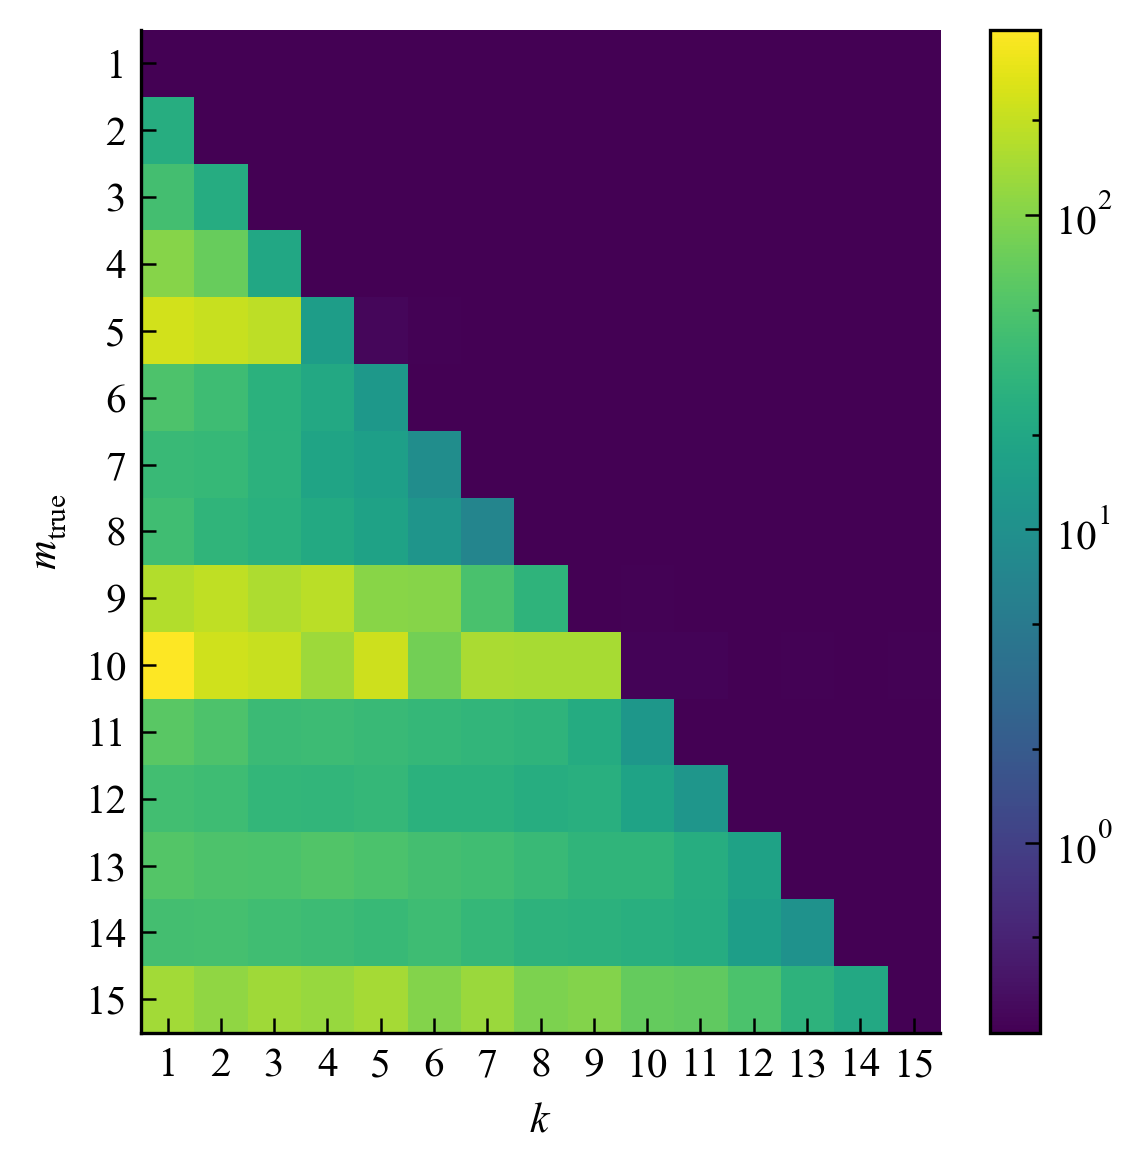

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm

d = 15
blocks = range(1, d+1)
eps = 1e-4
num_samples = 100

# This will store a row for each block size
final_heatmap_rows = []

for max_block_size in blocks:
    batch_features = []
    for _ in range(num_samples):
        superdiag = get_superdiagonal(max_block_size, d)
        J = np.diag(superdiag, k=1)
        S = np.random.randn(d, d)
        E = np.random.randn(d, d)
        rad = np.max(np.abs(np.linalg.eigvals(E)))
        if rad > 1:
            E /= rad
        A = np.linalg.inv(S) @ (J + eps * E) @ S
        batch_features.append(per_power_features(A))
    
    features_tensor = torch.tensor(np.array(batch_features), dtype=torch.float32)
    
    with torch.no_grad():
        # enc_outputs shape: [num_samples, seq_len, hidden_dim]
        _, _, enc_outputs = model(d, features_tensor, return_attention=True)
    
    # 1. Take norm over the hidden dimension: [num_samples, seq_len]
    # We use ord=2 for the standard Euclidean norm
    norms = torch.norm(enc_outputs, p=2, dim=2)
    
    # 2. Average the norms across all 100 samples: [seq_len]
    avg_norm_row = norms.mean(dim=0).detach().numpy()
    
    final_heatmap_rows.append(avg_norm_row)

# Stack all rows into a single matrix: [len(blocks), seq_len]
final_matrix = np.stack(final_heatmap_rows)

# Set up the single imshow plot
fig, ax = plt.subplots(figsize=(4,4))

# Shared color scale using AsinhNorm
vmin, vmax = final_matrix.min(), final_matrix.max()
norm = AsinhNorm(linear_width=0.1, vmin=vmin, vmax=vmax)
# norm=None

im = ax.imshow(final_matrix, aspect='auto', norm=norm, cmap='viridis')

# Formatting axes
# ax.set_title(f"Mean Hidden Vector Norm (eps={eps}, samples={num_samples})")
ax.set_xlabel("$k$")
ax.set_ylabel("$m_{\\mathrm{true}}$")

# Set x-ticks to match your sequence indices
ax.set_xticks(range(final_matrix.shape[1]))
ax.set_xticklabels([str(i) for i in range(1, final_matrix.shape[1] + 1)])

# Set y-ticks to match your block sizes
ax.set_yticks(range(len(blocks)))
ax.set_yticklabels([str(b) for b in blocks])

# Add colorbar
fig.colorbar(im)

plt.tight_layout()
plt.show()

In [8]:
attention_weights = attention_rollout(att_weights)

importance_scores = attention_weights.mean(dim=1)

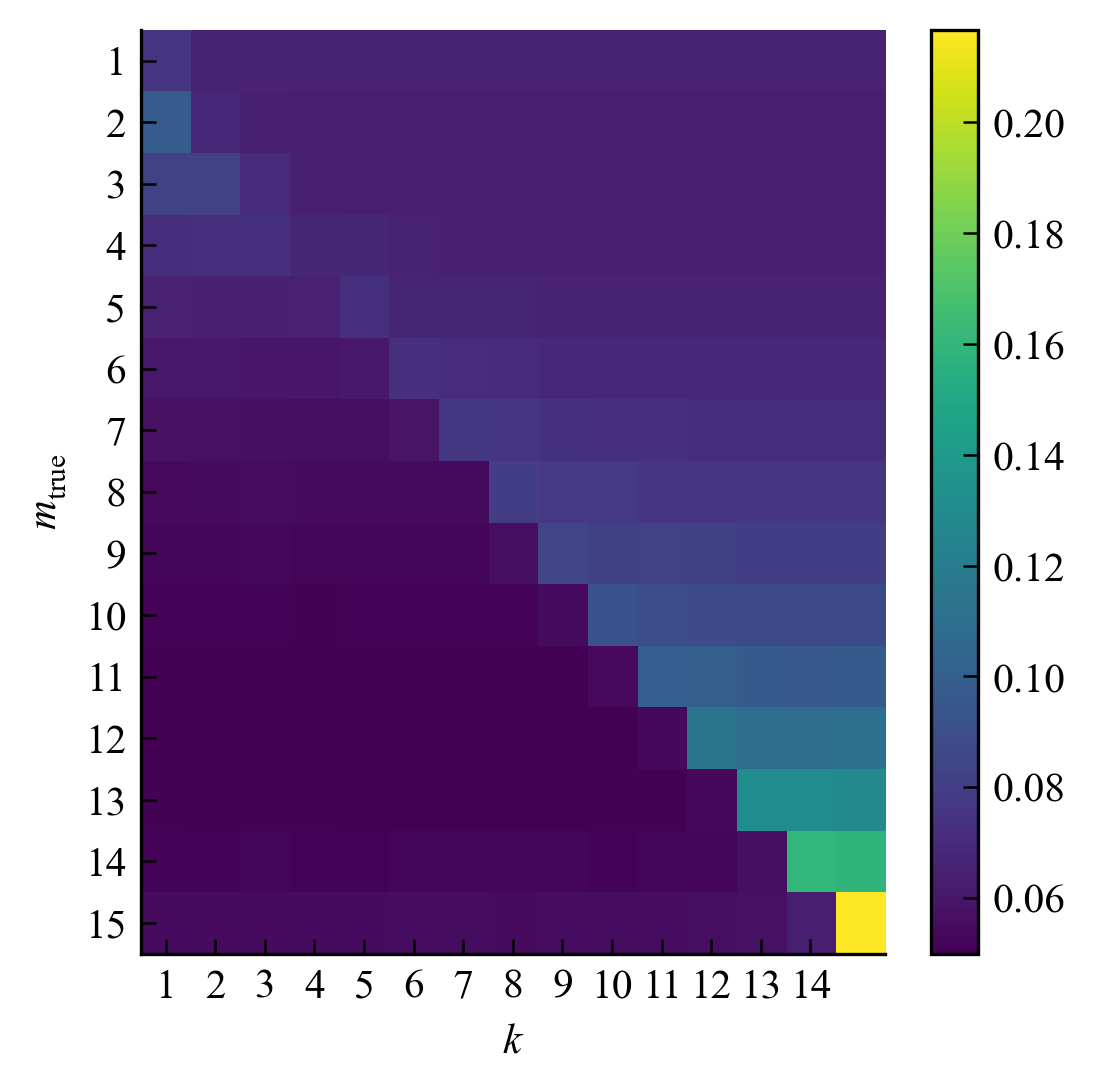

In [9]:
d = 15
blocks = range(1, d+1)
eps = 1e-4
num_samples = 100

all_importance_scores = []
all_probs = []

for max_block_size in blocks:
    matrices = []
    features = []

    for _ in range(num_samples):
        superdiag = get_superdiagonal(max_block_size, d)
        J = np.diag(superdiag, k=1)
        S = np.random.randn(d, d)
        E = np.random.randn(d, d)/np.sqrt(d)
        rad = np.max(np.abs(np.linalg.eigvals(E)))
        if rad > 1:
            E /= rad
        A = np.linalg.inv(S) @ (J + eps * E) @ S

        matrices.append(A)
        features.append(per_power_features(A))

    matrices = torch.tensor(matrices, dtype=torch.float32)
    features = torch.tensor(features, dtype=torch.float32)

    # --- model inference ---
    logits, att_weights, enc_outputs = model(d, features, return_attention=True)
    probs = torch.softmax(logits, dim=-1)

    attention_weights = attention_rollout(att_weights)
    importance_scores = attention_weights.mean(dim=1)

    # --- average over 100 samples ---
    avg_importance = importance_scores.mean(dim=0)
    avg_probs = probs.mean(dim=0)

    all_importance_scores.append(avg_importance.detach().numpy())
    all_probs.append(avg_probs.detach().numpy())

importance_matrix = np.stack(all_importance_scores)

plt.figure(figsize=(4, 4))

im = plt.imshow(importance_matrix, aspect='auto')

# axis labels
plt.yticks(range(len(blocks)), labels=[str(b) for b in blocks])
plt.xticks(range(d-1), labels=[str(i) for i in range(1, d)])

plt.xlabel("$k$")
plt.ylabel("$m_{\\mathrm{true}}$")

plt.colorbar(im)

plt.show()

# # --- plot probabilities ---
# for i, block in enumerate(blocks):
#     plt.plot(range(1, d+1), all_probs[i],
#              label=str(block), marker='x', alpha=.8)

# # plt.legend()
# plt.grid()
# plt.xticks(range(1, d+1), labels=[str(i) for i in range(1, d+1)])
# plt.show()


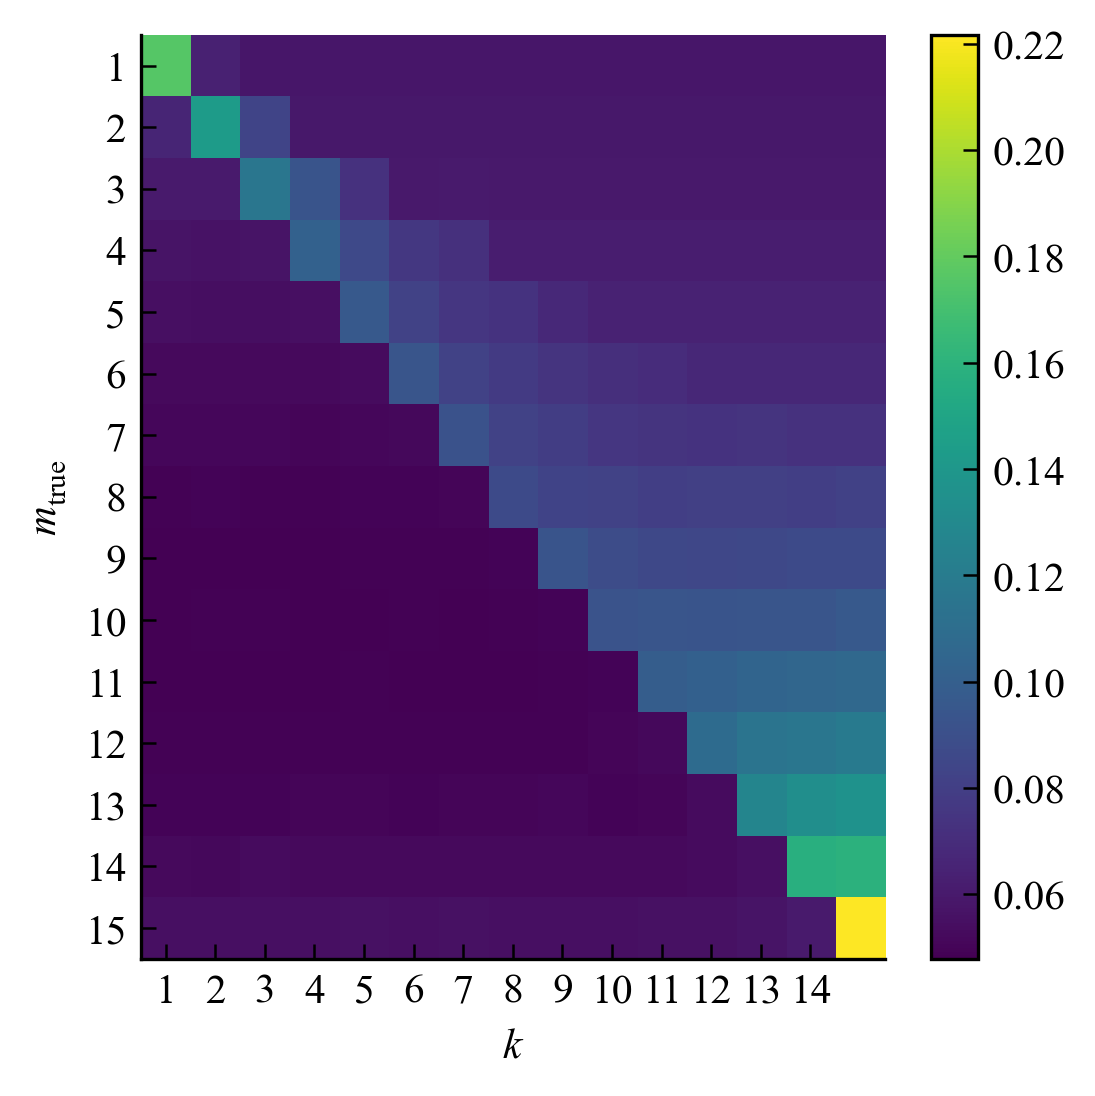

In [10]:
d = 15
blocks = range(1, d+1)
eps = 1e-2
num_samples = 100

all_importance_scores = []
all_probs = []

for max_block_size in blocks:
    matrices = []
    features = []

    # --- generate 100 matrices ---
    for _ in range(num_samples):
        superdiag = get_superdiagonal(max_block_size, d)
        J = np.diag(superdiag, k=1)
        S = np.random.randn(d, d)
        E = np.random.randn(d, d)/np.sqrt(d)
        rad = np.max(np.abs(np.linalg.eigvals(E)))
        if rad > 1:
            E /= rad
        A = np.linalg.inv(S) @ (J + eps * E) @ S

        matrices.append(A)
        features.append(per_power_features(A))

    matrices = torch.tensor(matrices, dtype=torch.float32)
    features = torch.tensor(features, dtype=torch.float32)

    # --- model inference ---
    logits, att_weights, enc_outputs = model(d, features, return_attention=True)
    probs = torch.softmax(logits, dim=-1)

    attention_weights = attention_rollout(att_weights)
    importance_scores = attention_weights.mean(dim=1)

    # --- average over 100 samples ---
    avg_importance = importance_scores.mean(dim=0)
    avg_probs = probs.mean(dim=0)

    all_importance_scores.append(avg_importance.detach().numpy())
    all_probs.append(avg_probs.detach().numpy())

importance_matrix = np.stack(all_importance_scores)

plt.figure(figsize=(4, 4))

im = plt.imshow(importance_matrix, aspect='auto')

# axis labels
plt.yticks(range(len(blocks)), labels=[str(b) for b in blocks])
plt.xticks(range(d-1), labels=[str(i) for i in range(1, d)])

plt.xlabel("$k$")
plt.ylabel("$m_{\\mathrm{true}}$")
# plt.title("Average Importance Scores")

plt.colorbar(im)

plt.show()

# # --- plot probabilities ---
# for i, block in enumerate(blocks):
#     plt.plot(range(1, d+1), all_probs[i],
#              label=str(block), marker='x', alpha=.8)

# # plt.legend()
# plt.grid()
# plt.xticks(range(1, d+1), labels=[str(i) for i in range(1, d+1)])
# plt.show()


In [11]:
# Parameters
d = 15
blocks = range(1, d + 1)
num_samples = 100
epsilons = [1e-4, 1e-2]

# Data storage to hold results for plotting
plot_data = {eps: {'encoder': None, 'attention': None} for eps in epsilons}

# Data Generation Loop
for eps in epsilons:
    enc_rows = []
    att_rows = []
    
    for max_block_size in blocks:
        batch_features = []
        for _ in range(num_samples):
            superdiag = get_superdiagonal(max_block_size, d)
            J = np.diag(superdiag, k=1)
            S = np.random.randn(d, d)
            E = np.random.randn(d, d)/np.sqrt(d)
            rad = np.max(np.abs(np.linalg.eigvals(E)))
            if rad > 1:
                E /= rad
            A = np.linalg.inv(S) @ (J + eps * E) @ S
            batch_features.append(per_power_features(A))
        
        features_tensor = torch.tensor(np.array(batch_features), dtype=torch.float32)
        
        with torch.no_grad():
            logits, att_weights, enc_outputs = model(d, features_tensor, return_attention=True)
        
        # 1. Process Encoder Output Norms
        norms = torch.norm(enc_outputs, p=2, dim=2)
        avg_norm_row = norms.mean(dim=0).detach().numpy()
        enc_rows.append(avg_norm_row)
        
        # 2. Process Attention Weights
        rollout = attention_rollout(att_weights)
        importance_scores = rollout.mean(dim=1)
        avg_importance = importance_scores.mean(dim=0).detach().numpy()
        att_rows.append(avg_importance)

    plot_data[eps]['encoder'] = np.stack(enc_rows)
    plot_data[eps]['attention'] = np.stack(att_rows)

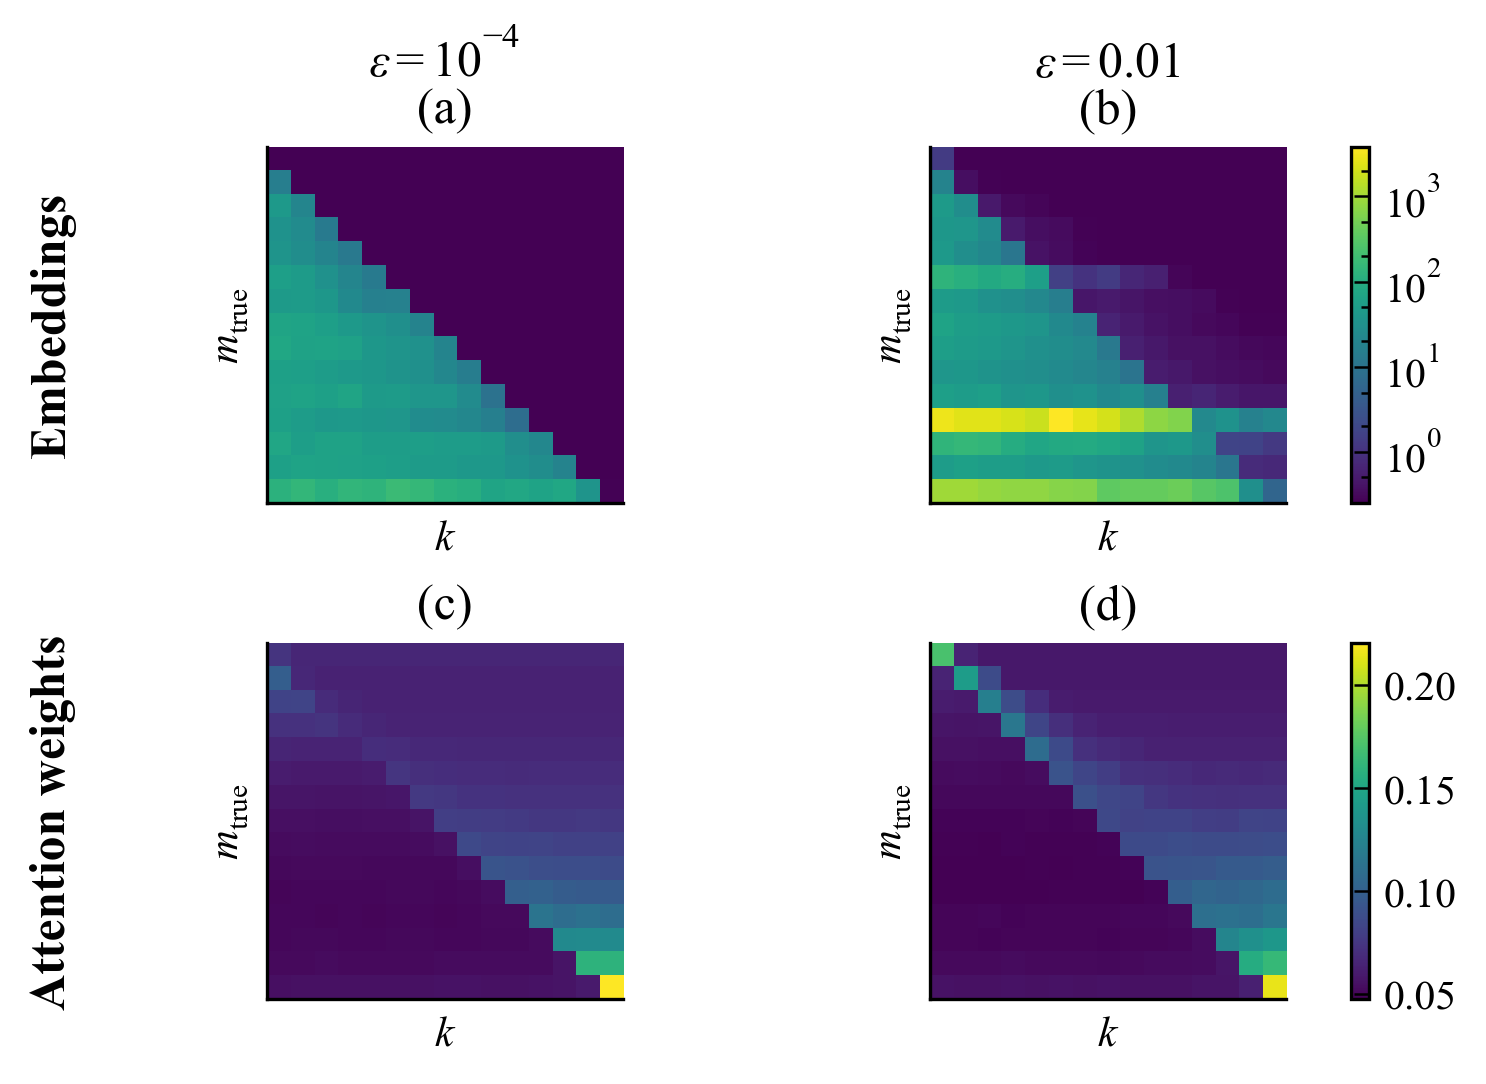

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm

# --- Plotting ---
fig, axes = plt.subplots(2, 2, constrained_layout=True)

# Define Shared Scales
v_enc_min = min(plot_data[1e-4]['encoder'].min(), plot_data[1e-2]['encoder'].min())
v_enc_max = max(plot_data[1e-4]['encoder'].max(), plot_data[1e-2]['encoder'].max())
norm_enc = AsinhNorm(linear_width=0.1, vmin=v_enc_min, vmax=v_enc_max)

v_att_min = min(plot_data[1e-4]['attention'].min(), plot_data[1e-2]['attention'].min())
v_att_max = max(plot_data[1e-4]['attention'].max(), plot_data[1e-2]['attention'].max())

# Plotting: Row 0 = Embeddings, Row 1 = Attention
# Column 0 = 1e-4, Column 1 = 1e-2
im_a = axes[0, 0].imshow(plot_data[1e-4]['encoder'], aspect='equal', norm=norm_enc, cmap='viridis')
im_b = axes[0, 1].imshow(plot_data[1e-2]['encoder'], aspect='equal', norm=norm_enc, cmap='viridis')
im_c = axes[1, 0].imshow(plot_data[1e-4]['attention'], aspect='equal', vmin=v_att_min, vmax=v_att_max, cmap='viridis')
im_d = axes[1, 1].imshow(plot_data[1e-2]['attention'], aspect='equal', vmin=v_att_min, vmax=v_att_max, cmap='viridis')

# Add Titles (a), (b), (c), (d)
axes[0, 0].set_title(r"(a)")
axes[0, 1].set_title(r"(b)")
axes[1, 0].set_title(r"(c)")
axes[1, 1].set_title(r"(d)")

# --- Add Row and Column Captions ---
# Column Labels (Epsilons)
axes[0, 0].annotate(r"$\epsilon = 10^{-4}$", xy=(0.5, 1.2), xycoords='axes fraction', 
                    ha='center', va='baseline', fontsize='large', fontweight='bold')
axes[0, 1].annotate(r"$\epsilon = 0.01$", xy=(0.5, 1.2), xycoords='axes fraction', 
                    ha='center', va='baseline', fontsize='large', fontweight='bold')

# Row Labels (Embeddings/Attention)
axes[0, 0].annotate("Embeddings", xy=(-0.6, 0.5), xycoords='axes fraction', 
                    rotation=90, ha='center', va='center', fontsize='large', fontweight='bold')
axes[1, 0].annotate("Attention weights", xy=(-0.6, 0.5), xycoords='axes fraction', 
                    rotation=90, ha='center', va='center', fontsize='large', fontweight='bold')

# Formatting Ticks and Labels
for ax in axes.flat:
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$m_{\mathrm{true}}$")
    ax.set_xticks([])
    ax.set_yticks([])

# Add Colorbars (shared by rows)
fig.colorbar(im_a, ax=[axes[0, 0], axes[0, 1]], shrink=1)
fig.colorbar(im_c, ax=[axes[1, 0], axes[1, 1]], shrink=1)

plt.savefig("latex/images/j8_attention.pdf")
plt.show()